### Project Objective

The goal of this project is NOT to predict exact stock prices for trading.
Instead, we aim to:

1. Learn temporal patterns from historical stock data using LSTM
2. Predict short-term price direction (Up / Down)
3. Forecast future price movement trends
4. Demonstrate how deep learning can be applied responsibly to financial time series


### Data Source

We use historical stock price data from Tiingo via REST API.
Using an API instead of CSV reflects real-world data engineering practices.


In [1]:
import requests
import pandas as pd

API_KEY = "e9b0c2b7355065e174e3e3a47fe6e0e9464a070b"

url = "https://api.tiingo.com/tiingo/daily/AAPL/prices"
headers = {"Authorization": f"Token {API_KEY}"}

params = {
    "startDate": "2015-01-01",
    "endDate": "2024-01-01"
}

response = requests.get(url, headers=headers, params=params)
df = pd.DataFrame(response.json())

In [2]:
df.head()

,date,close,high,low,open,volume,adjClose,adjHigh,adjLow,adjOpen,adjVolume,divCash,splitFactor
0,2015-01-02T00:00:00.000Z,109.33,111.44,107.350,111.39,53204626,24.215164,24.682502,23.776620,24.671427,212818504,0.0,1.0
1,2015-01-05T00:00:00.000Z,106.25,108.65,105.410,108.29,64285491,23.532985,24.064553,23.346936,23.984818,257141964,0.0,1.0
2,2015-01-06T00:00:00.000Z,106.26,107.43,104.630,106.54,65797116,23.535199,23.794339,23.174176,23.597216,263188464,0.0,1.0
3,2015-01-07T00:00:00.000Z,107.75,108.20,106.695,107.20,40105934,23.865215,23.964884,23.631546,23.743397,160423736,0.0,1.0
4,2015-01-08T00:00:00.000Z,111.89,112.15,108.700,109.23,59364547,24.782171,24.839757,24.075627,24.193016,237458188,0.0,1.0


### Data Preparation

We clean and structure the dataset for time-series analysis.
Dates are set as index to preserve temporal order.


In [3]:
df["date"] = pd.to_datetime(df["date"])
df.set_index("date", inplace=True)

df = df[["open", "high", "low", "close", "volume"]]

<Axes: title={'center': 'AAPL Closing Price Over Time'}, xlabel='date'>

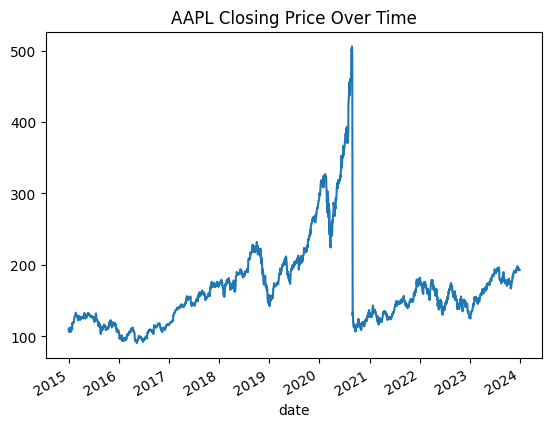

In [4]:
df["close"].plot(title="AAPL Closing Price Over Time")

In [5]:
price_stats = pd.DataFrame({
    'Metric': ['Mean Price', 'Median Price', 'Min Price', 'Max Price',
               'Start Price', 'End Price', 'Total Change', 'Percent Change'],
    'Value': [
        f"${df['close'].mean():.2f}",
        f"${df['close'].median():.2f}",
        f"${df['close'].min():.2f}",
        f"${df['close'].max():.2f}",
        f"${df['close'].iloc[0]:.2f}",
        f"${df['close'].iloc[-1]:.2f}",
        f"${df['close'].iloc[-1] - df['close'].iloc[0]:.2f}",
        f"{((df['close'].iloc[-1] / df['close'].iloc[0] - 1) * 100):.2f}%"
    ]
})

print("\n📊 AAPL Closing Price Statistics")
print("="*50)
print(price_stats.to_string(index=False))


📊 AAPL Closing Price Statistics
        Metric   Value
    Mean Price $166.79
  Median Price $153.84
     Min Price  $90.34
     Max Price $506.09
   Start Price $109.33
     End Price $192.53
  Total Change  $83.20
Percent Change  76.10%


### Exploratory Data Analysis

EDA helps us understand trends, volatility, and noise in the data.


<Axes: title={'center': 'Daily Returns'}, xlabel='date'>

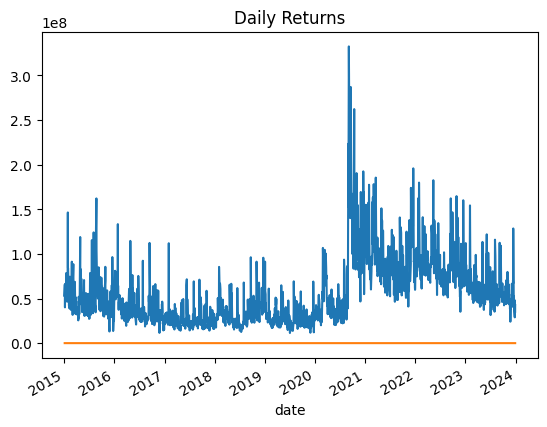

In [6]:
df["volume"].plot(title="Trading Volume Over Time")
df["close"].pct_change().plot(title="Daily Returns")

In [7]:
volume_stats = pd.DataFrame({
    'Metric': ['Average Daily Volume', 'Median Volume', 'Min Volume',
               'Max Volume', 'Total Volume', 'Std Deviation'],
    'Value': [
        f"{df['volume'].mean():,.0f}",
        f"{df['volume'].median():,.0f}",
        f"{df['volume'].min():,.0f}",
        f"{df['volume'].max():,.0f}",
        f"{df['volume'].sum():,.0f}",
        f"{df['volume'].std():,.0f}"
    ]
})

print("\n📊 Trading Volume Statistics")
print("="*50)
print(volume_stats.to_string(index=False))


📊 Trading Volume Statistics
              Metric           Value
Average Daily Volume      54,415,669
       Median Volume      45,149,748
          Min Volume      11,362,045
          Max Volume     332,607,163
        Total Volume 123,197,075,158
       Std Deviation      34,813,155


### Feature Engineering

Raw prices are transformed into meaningful indicators that capture:
- Trend
- Momentum
- Volatility


In [8]:
df["return"] = df["close"].pct_change()
df["ma_10"] = df["close"].rolling(10).mean()
df["ma_30"] = df["close"].rolling(30).mean()
df["volatility"] = df["return"].rolling(10).std()
df["price_range"] = df["high"] - df["low"]

df.dropna(inplace=True)

In [9]:
returns = df["close"].pct_change().dropna()
returns_stats = pd.DataFrame({
    'Metric': ['Mean Daily Return', 'Median Daily Return', 'Std Deviation (Volatility)',
               'Min Daily Return', 'Max Daily Return', 'Positive Days',
               'Negative Days', 'Win Rate'],
    'Value': [
        f"{returns.mean()*100:.4f}%",
        f"{returns.median()*100:.4f}%",
        f"{returns.std()*100:.4f}%",
        f"{returns.min()*100:.2f}%",
        f"{returns.max()*100:.2f}%",
        f"{(returns > 0).sum()}",
        f"{(returns < 0).sum()}",
        f"{(returns > 0).sum() / len(returns) * 100:.2f}%"
    ]
})

print("\n📊 Daily Returns Statistics")
print("="*50)
print(returns_stats.to_string(index=False))


📊 Daily Returns Statistics
                    Metric   Value
         Mean Daily Return 0.0627%
       Median Daily Return 0.0757%
Std Deviation (Volatility) 2.4085%
          Min Daily Return -74.15%
          Max Daily Return  11.98%
             Positive Days    1172
             Negative Days    1057
                  Win Rate  52.46%


<Axes: title={'center': 'Price vs Moving Averages'}, xlabel='date'>

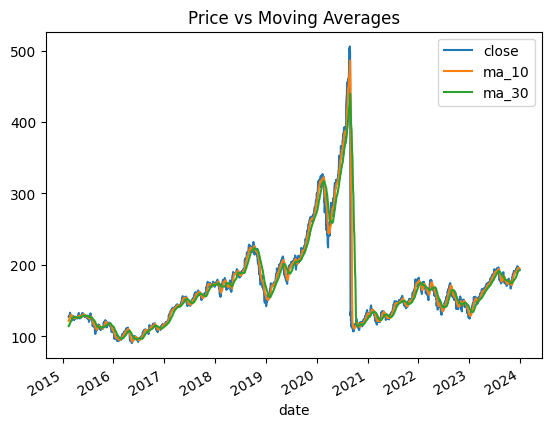

In [10]:
df[["close", "ma_10", "ma_30"]].plot(title="Price vs Moving Averages")

### Target Variable

We define a binary target:

1 → Next day price goes UP  
0 → Next day price goes DOWN


In [11]:
df["target"] = (df["close"].shift(-1) > df["close"]).astype(int)
df.dropna(inplace=True)

### Train–Test Split

We split data chronologically to avoid future leakage.


In [12]:
split = int(len(df) * 0.8)
train = df.iloc[:split]
test = df.iloc[split:]

### Feature Scaling

Neural networks require scaled input for stable learning.


In [13]:
from sklearn.preprocessing import MinMaxScaler

features = [
    "open","high","low","close","volume",
    "ma_10","ma_30","volatility","price_range"
]

scaler = MinMaxScaler()

X_train = scaler.fit_transform(train[features])
X_test = scaler.transform(test[features])

y_train = train["target"]
y_test = test["target"]

### Sequence Generation

LSTM models learn from sequences, not individual rows.
We use a rolling window of past 20 days.


In [14]:
import numpy as np

def create_sequences(X, y, window=20):
    Xs, ys = [], []
    for i in range(window, len(X)):
        Xs.append(X[i-window:i])
        ys.append(y.iloc[i])
    return np.array(Xs), np.array(ys)

X_train_seq, y_train_seq = create_sequences(X_train, y_train)
X_test_seq, y_test_seq = create_sequences(X_test, y_test)

### LSTM Model Architecture

We use a stacked LSTM to capture temporal dependencies.


In [15]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout

model = Sequential([
    LSTM(64, return_sequences=True,
         input_shape=(X_train_seq.shape[1], X_train_seq.shape[2])),
    Dropout(0.3),
    LSTM(32),
    Dropout(0.2),
    Dense(1, activation="sigmoid")
])

model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [16]:
history = model.fit(
    X_train_seq, y_train_seq,
    epochs=25,
    batch_size=32,
    validation_split=0.1
)

Epoch 1/25
50/50 ━━━━━━━━━━━━━━━━━━━━ 6s 34ms/step - accuracy: 0.5176 - loss: 0.6937 - val_accuracy: 0.5141 - val_loss: 0.6934
Epoch 2/25
50/50 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - accuracy: 0.5023 - loss: 0.6929 - val_accuracy: 0.5141 - val_loss: 0.6961
Epoch 3/25
50/50 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - accuracy: 0.5192 - loss: 0.6944 - val_accuracy: 0.5141 - val_loss: 0.6933
Epoch 4/25
50/50 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - accuracy: 0.4942 - loss: 0.6959 - val_accuracy: 0.5141 - val_loss: 0.6937
Epoch 5/25
50/50 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - accuracy: 0.5388 - loss: 0.6912 - val_accuracy: 0.5141 - val_loss: 0.6931
Epoch 6/25
50/50 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - accuracy: 0.5372 - loss: 0.6929 - val_accuracy: 0.5141 - val_loss: 0.6931
Epoch 7/25
50/50 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - accuracy: 0.5143 - loss: 0.6920 - val_accuracy: 0.5141 - val_loss: 0.6938
Epoch 8/25
50/50 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - accuracy: 0.5227 - loss: 0.6926 - val_accuracy: 0.5141 - v

<Axes: title={'center': 'Training vs Validation Loss'}>

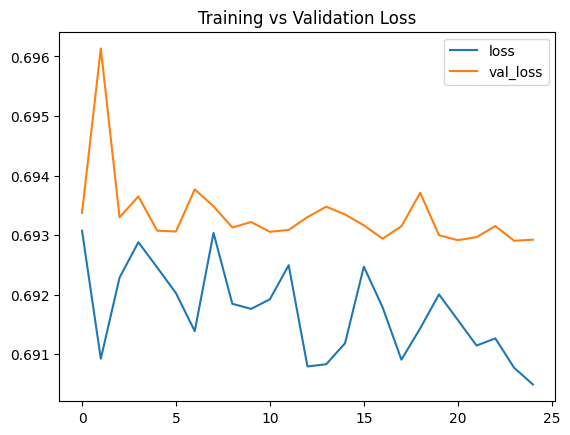

In [17]:
pd.DataFrame(history.history)[["loss","val_loss"]].plot(title="Training vs Validation Loss")

### Model Evaluation

We evaluate classification performance on unseen data.


In [18]:
from sklearn.metrics import classification_report, confusion_matrix

preds = (model.predict(X_test_seq) > 0.5).astype(int)

print(classification_report(y_test_seq, preds))
print(confusion_matrix(y_test_seq, preds))

14/14 ━━━━━━━━━━━━━━━━━━━━ 1s 37ms/step
              precision    recall  f1-score   support

           0       0.52      0.05      0.10       204
           1       0.52      0.96      0.68       223

    accuracy                           0.52       427
   macro avg       0.52      0.50      0.39       427
weighted avg       0.52      0.52      0.40       427

[[ 11 193]
 [ 10 213]]


### Price Forecasting using LSTM

We now use the trained LSTM to forecast future price movement trends.
This is exploratory and NOT a trading signal.


In [19]:
last_sequence = X_test_seq[-1]

future_steps = 10
forecast = []

current_seq = last_sequence.copy()

for _ in range(future_steps):
    pred = model.predict(current_seq.reshape(1, *current_seq.shape))
    forecast.append(pred[0][0])
    current_seq = np.roll(current_seq, -1, axis=0)
    current_seq[-1, -1] = pred

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step


/tmp/ipython-input-188117071.py:12: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  current_seq[-1, -1] = pred


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step


In [20]:
import matplotlib.pyplot as plt

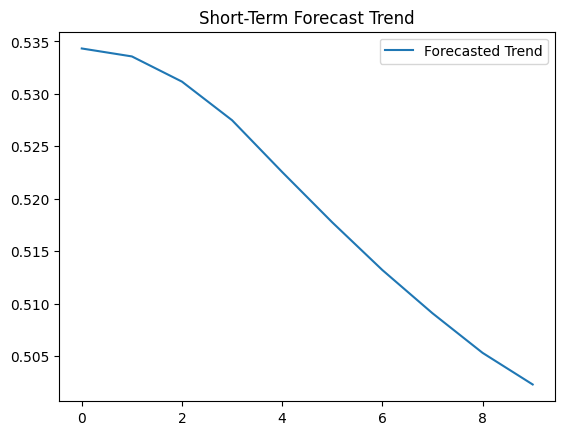

In [21]:
plt.plot(forecast, label="Forecasted Trend")
plt.title("Short-Term Forecast Trend")
plt.legend()

### Key Insights

- LSTM captures short-term momentum and volatility patterns
- Predictive performance is modest, which is expected in financial markets
- The model is suitable for decision support, not automated trading

### Limitations

- Market efficiency
- No sentiment or macroeconomic features
- Transaction costs not modeled
